In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import nltk
import re

In [191]:
df1=pd.read_csv('SMS_train.csv',encoding='latin1')
df2=pd.read_csv('SMS_test.csv',encoding='latin1')
df1

,S. No.,Message_body,Label
0,1,Rofl. Its true to its name,Non-Spam
1,2,The guy did some bitching but I acted like i'd...,Non-Spam
2,3,"Pity, * was in mood for that. So...any other s...",Non-Spam
3,4,Will ü b going to esplanade fr home?,Non-Spam
4,5,This is the 2nd time we have tried 2 contact u...,Spam
...,...,...,...
952,953,hows my favourite person today? r u workin har...,Non-Spam
953,954,How much you got for cleaning,Non-Spam
954,955,Sorry da. I gone mad so many pending works wha...,Non-Spam
955,956,Wat time ü finish?,Non-Spam


In [192]:
df2

,S. No.,Message_body,Label
0,1,"UpgrdCentre Orange customer, you may now claim...",Spam
1,2,"Loan for any purpose £500 - £75,000. Homeowner...",Spam
2,3,Congrats! Nokia 3650 video camera phone is you...,Spam
3,4,URGENT! Your Mobile number has been awarded wi...,Spam
4,5,Someone has contacted our dating service and e...,Spam
...,...,...,...
120,121,7 wonders in My WORLD 7th You 6th Ur style 5th...,Non-Spam
121,122,Try to do something dear. You read something f...,Non-Spam
122,123,Sun ah... Thk mayb can if dun have anythin on....,Non-Spam
123,124,"SYMPTOMS when U are in love: ""1.U like listeni...",Non-Spam


In [193]:
df=pd.concat([df1,df2],axis=0)
df

,S. No.,Message_body,Label
0,1,Rofl. Its true to its name,Non-Spam
1,2,The guy did some bitching but I acted like i'd...,Non-Spam
2,3,"Pity, * was in mood for that. So...any other s...",Non-Spam
3,4,Will ü b going to esplanade fr home?,Non-Spam
4,5,This is the 2nd time we have tried 2 contact u...,Spam
...,...,...,...
120,121,7 wonders in My WORLD 7th You 6th Ur style 5th...,Non-Spam
121,122,Try to do something dear. You read something f...,Non-Spam
122,123,Sun ah... Thk mayb can if dun have anythin on....,Non-Spam
123,124,"SYMPTOMS when U are in love: ""1.U like listeni...",Non-Spam


In [194]:
df.reset_index(drop=True,inplace=True)

In [195]:
df.isna().sum()

S. No.          0
Message_body    0
Label           0
dtype: int64

In [196]:
df.dtypes

S. No.           int64
Message_body    object
Label           object
dtype: object

In [197]:
df.drop(['S. No.'],axis=1,inplace=True)
df

,Message_body,Label
0,Rofl. Its true to its name,Non-Spam
1,The guy did some bitching but I acted like i'd...,Non-Spam
2,"Pity, * was in mood for that. So...any other s...",Non-Spam
3,Will ü b going to esplanade fr home?,Non-Spam
4,This is the 2nd time we have tried 2 contact u...,Spam
...,...,...
1077,7 wonders in My WORLD 7th You 6th Ur style 5th...,Non-Spam
1078,Try to do something dear. You read something f...,Non-Spam
1079,Sun ah... Thk mayb can if dun have anythin on....,Non-Spam
1080,"SYMPTOMS when U are in love: ""1.U like listeni...",Non-Spam


In [198]:
df.shape

(1082, 2)

In [199]:
df.duplicated().sum()
df = df.drop_duplicates()
df.reset_index(drop=True,inplace=True)

In [200]:
df.isna().value_counts()

Message_body  Label
False         False    1064
Name: count, dtype: int64

In [201]:
df

,Message_body,Label
0,Rofl. Its true to its name,Non-Spam
1,The guy did some bitching but I acted like i'd...,Non-Spam
2,"Pity, * was in mood for that. So...any other s...",Non-Spam
3,Will ü b going to esplanade fr home?,Non-Spam
4,This is the 2nd time we have tried 2 contact u...,Spam
...,...,...
1059,7 wonders in My WORLD 7th You 6th Ur style 5th...,Non-Spam
1060,Try to do something dear. You read something f...,Non-Spam
1061,Sun ah... Thk mayb can if dun have anythin on....,Non-Spam
1062,"SYMPTOMS when U are in love: ""1.U like listeni...",Non-Spam


In [202]:
x=df['Message_body']
y=df['Label']

In [203]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [204]:
for i in [x_train,x_test,y_train,y_test]:
    print(i)
    print('SHAPE : ',i.shape)
    print('*')

5       REMINDER FROM O2: To get 2.50 pounds free call...
310                                 Ok... Sweet dreams...
892                        No. Yes please. Been swimming?
104     Shall I bring us a bottle of wine to keep us a...
97      Well obviously not because all the people in m...
                              ...                        
330                                 Ok cool. See ya then.
466     Hi Shanil,Rakhesh here.thanks,i have exchanged...
121                 So that takes away some money worries
1044                       Omg how did u know what I ate?
860     URGENT! Your Mobile No 07808726822 was awarded...
Name: Message_body, Length: 744, dtype: object
SHAPE :  (744,)
*
31                             Just sleeping..and surfing
1053                            How much u trying to get?
413                          Pls call me da. What happen.
746     Don't worry though, I understand how important...
796     Thanks 4 your continued support Your question ...
       

In [205]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [206]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

In [207]:
models={
    "Naive_bayes": MultinomialNB(),
    "Logistic_Regression":LogisticRegression(),
    "SVM":SVC(),
    'Random_Forest':RandomForestClassifier(),
    'Decision_Tree':DecisionTreeClassifier(),
    'Gradient_Boosting':GradientBoostingClassifier(),
    'KNN':KNeighborsClassifier(n_neighbors=7)
}

In [208]:
dfm=[]
for name,model in models.items():
    pipe=Pipeline([('tfidf',TfidfVectorizer()),('model',model)])
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    acc=accuracy_score(y_pred,y_test)*100
    print(f"{name} : {acc}")
    dfm.append([name,acc])

Naive_bayes : 89.6875
Logistic_Regression : 89.375
SVM : 93.75
Random_Forest : 93.75
Decision_Tree : 94.0625
Gradient_Boosting : 94.0625
KNN : 94.375


In [209]:
df_model=pd.DataFrame(dfm,columns=['Model_Name','Accuracy'])
df_model

,Model_Name,Accuracy
0,Naive_bayes,89.6875
1,Logistic_Regression,89.3750
2,SVM,93.7500
3,Random_Forest,93.7500
4,Decision_Tree,94.0625
5,Gradient_Boosting,94.0625
6,KNN,94.3750


In [213]:
df_model = df_model.sort_values(by='Accuracy', ascending=False)
df_model

,Model_Name,Accuracy
6,KNN,94.3750
4,Decision_Tree,94.0625
5,Gradient_Boosting,94.0625
2,SVM,93.7500
3,Random_Forest,93.7500
0,Naive_bayes,89.6875
1,Logistic_Regression,89.3750


In [215]:
best_model = df_model.iloc[0]

print(best_model)

Model_Name       KNN
Accuracy      94.375
Name: 6, dtype: object


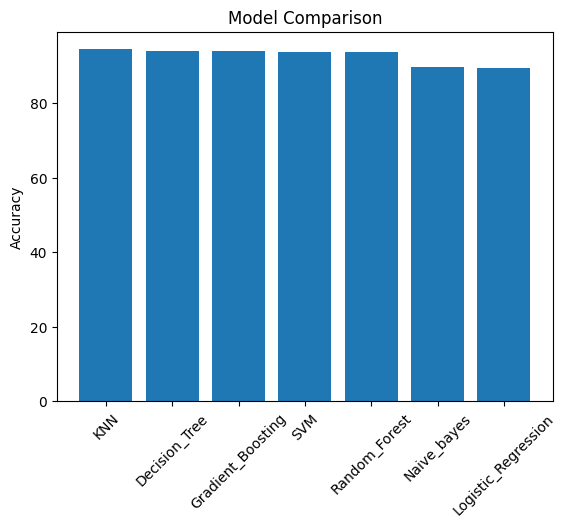

In [216]:
import matplotlib.pyplot as plt

plt.bar(df_model['Model_Name'], df_model['Accuracy'])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [217]:
best_pipe=Pipeline([('ifidf',TfidfVectorizer()),('model',KNeighborsClassifier(n_neighbors=7))])
best_pipe.fit(x_train,y_train)

,steps,"[('ifidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [223]:
msg = ["Congratulations! You have won a free ticket"]

In [224]:
pred1=best_pipe.predict(msg)
print(pred1)

['Spam']
